# Análisis de resultados — CMLC / BR / HPS MTL / NDDR MTL

Replica las comparaciones y gráficos del paper (Olcay et al. 2026, *"How to
analyse overlapping sounds in the marine environment using supervised
multi-label classification"*) usando los resultados generados en Khipu para
los 4 sistemas, adaptados al dataset de anuros de la Amazonía (5 especies).

**Este notebook corre con los sistemas que ya tengas disponibles.** Si falta
HPS MTL y/o NDDR MTL, esas secciones se saltan automáticamente con un aviso
— no hace falta esperar a tenerlos todos para poder ejecutarlo. Vuelve a
correr el notebook completo cuando agregues las carpetas que falten.

## Cómo usar este notebook

1. Copia las carpetas `resultados/{sistema}/` que ya tengas (`cmlc/`, `br/`,
   y más adelante `hps/`, `nddr/`) a la misma carpeta donde está este notebook,
   manteniendo la estructura `resultados/cmlc/results_final.csv`, etc.
2. Ajusta `RESULTS_DIR` en la siguiente celda si usas otra ruta.
3. `Kernel > Restart & Run All`.


## 1. Configuración

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "resultados"   # carpeta con subcarpetas cmlc/, br/, hps/, nddr/
SYSTEMS = ["cmlc", "br", "hps", "nddr"]
SYSTEM_LABELS = {"cmlc": "CMLC", "br": "BR", "hps": "HPS MTL", "nddr": "NDDR MTL"}
SYSTEM_COLORS = {"cmlc": "#1f77b4", "br": "#d62728", "hps": "#bcbd22", "nddr": "#2ca02c"}


In [4]:
def system_dir(system):
    return os.path.join(RESULTS_DIR, system)

def has_results(system):
    return os.path.exists(os.path.join(system_dir(system), "results_final.csv"))

available = [s for s in SYSTEMS if has_results(s)]
missing = [s for s in SYSTEMS if s not in available]

print(f"Sistemas disponibles: {[SYSTEM_LABELS[s] for s in available]}")
if missing:
    print(f"Sistemas AUN NO disponibles (se omiten en las secciones que los necesiten): "
          f"{[SYSTEM_LABELS[s] for s in missing]}")


Sistemas disponibles: ['CMLC', 'BR', 'HPS MTL', 'NDDR MTL']


## 2. Carga de resultados

Cada sistema disponible aporta:
- `results_final.csv`: precision/recall/F1/support por especie y fold (evaluado con el modelo al final del entrenamiento)
- `results_epochs.csv`: curvas de entrenamiento (loss, F1, tiempo por época)
- `used_dataset.csv`: el subconjunto exacto de clips usado (debería ser idéntico entre sistemas, misma semilla)


In [5]:
final_dfs = {}
epochs_dfs = {}
used_dfs = {}

for s in available:
    d = system_dir(s)
    final_dfs[s] = pd.read_csv(os.path.join(d, "results_final.csv"))
    epochs_path = os.path.join(d, "results_epochs.csv")
    if os.path.exists(epochs_path):
        epochs_dfs[s] = pd.read_csv(epochs_path)
    used_path = os.path.join(d, "used_dataset.csv")
    if os.path.exists(used_path):
        used_dfs[s] = pd.read_csv(used_path)
    print(f"{SYSTEM_LABELS[s]}: {len(final_dfs[s])} filas en results_final.csv "
          f"({final_dfs[s]['fold'].nunique()} folds x {final_dfs[s]['class'].nunique()} clases)")


CMLC: 25 filas en results_final.csv (5 folds x 5 clases)
BR: 25 filas en results_final.csv (5 folds x 5 clases)
HPS MTL: 25 filas en results_final.csv (5 folds x 5 clases)
NDDR MTL: 25 filas en results_final.csv (5 folds x 5 clases)


In [6]:
# Verificar que todos los sistemas usaron el MISMO subconjunto de datos
# (mismo seed/config -> deberia ser identico; si no, los resultados no son
# directamente comparables entre sistemas)
if len(used_dfs) >= 2:
    ref_system = list(used_dfs.keys())[0]
    ref_filenames = set(used_dfs[ref_system]["filename"])
    print(f"Verificando consistencia del dataset usado (referencia: {SYSTEM_LABELS[ref_system]}, "
          f"{len(ref_filenames)} clips)...")
    for s, df in used_dfs.items():
        if s == ref_system:
            continue
        same = set(df["filename"]) == ref_filenames
        print(f"  {SYSTEM_LABELS[s]}: {'IDENTICO' if same else 'DISTINTO -- revisar config'} "
              f"({len(df)} clips)")
else:
    print("Solo hay used_dataset.csv de un sistema disponible; no se puede verificar consistencia todavia.")


Verificando consistencia del dataset usado (referencia: CMLC, 10000 clips)...
  BR: IDENTICO (10000 clips)
  HPS MTL: IDENTICO (10000 clips)
  NDDR MTL: IDENTICO (10000 clips)


## 3. Accuracy y Exact Match (Ecuaciones 1 y 2 del paper)

Estas son las metricas principales que usa el paper para comparar los 4
sistemas (su Fig. 1 y discusion de resultados). Se calculan con
`compute_paper_metrics.py` -- un script aparte que corre inferencia sobre los
folds de validacion usando los checkpoints ya entrenados (sin reentrenar).

Si todavia no corriste `compute_paper_metrics_khipu.sh <sistema>` para alguno
de tus sistemas disponibles, esa sección se salta con un aviso.


In [7]:
paper_metrics_dfs = {}
for s in available:
    path = os.path.join(system_dir(s), "results_paper_metrics.csv")
    if os.path.exists(path):
        paper_metrics_dfs[s] = pd.read_csv(path)
    else:
        print(f"{SYSTEM_LABELS[s]}: falta results_paper_metrics.csv -- correr "
              f"'sbatch compute_paper_metrics_khipu.sh {s}' primero.")

pm_available = list(paper_metrics_dfs.keys())
print(f"\nSistemas con Accuracy/Exact Match calculados: {[SYSTEM_LABELS[s] for s in pm_available]}")



Sistemas con Accuracy/Exact Match calculados: ['CMLC', 'BR', 'HPS MTL', 'NDDR MTL']


In [8]:
if pm_available:
    print("=== Accuracy y Exact Match promedio por sistema (Tabla 1 estilo paper) ===")
    print(f"{'Sistema':<12}{'Accuracy':>12}{'Exact Match':>15}")
    for s in pm_available:
        df = paper_metrics_dfs[s]
        print(f"{SYSTEM_LABELS[s]:<12}{df['accuracy'].mean():>12.4f}{df['exact_match'].mean():>15.4f}")


=== Accuracy y Exact Match promedio por sistema (Tabla 1 estilo paper) ===
Sistema         Accuracy    Exact Match
CMLC              0.9654         0.8475
BR                0.9680         0.8564
HPS MTL           0.9669         0.8539
NDDR MTL          0.9688         0.8612


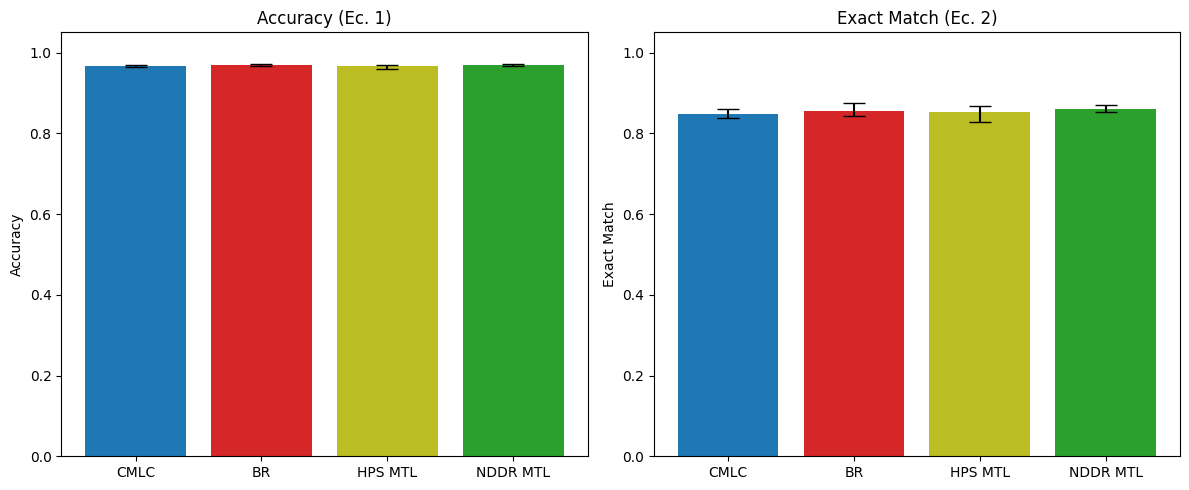

In [9]:
if pm_available:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    labels = [SYSTEM_LABELS[s] for s in pm_available]
    colors_list = [SYSTEM_COLORS[s] for s in pm_available]

    for ax, metric, title in [(axes[0], "accuracy", "Accuracy (Ec. 1)"),
                               (axes[1], "exact_match", "Exact Match (Ec. 2)")]:
        means = [paper_metrics_dfs[s][metric].mean() for s in pm_available]
        mins = [means[i] - paper_metrics_dfs[s][metric].min() for i, s in enumerate(pm_available)]
        maxs = [paper_metrics_dfs[s][metric].max() - means[i] for i, s in enumerate(pm_available)]
        ax.bar(labels, means, yerr=[mins, maxs], capsize=8, color=colors_list)
        ax.set_ylim(0, 1.05)
        ax.set_title(title)
        ax.set_ylabel(metric.replace("_", " ").title())

    plt.tight_layout()
    plt.savefig("accuracy_exact_match_por_sistema.png", dpi=120)
    plt.show()


**Nota sobre Exact Match:** es una métrica mucho más estricta que el F1 —
exige que las 5 especies coincidan simultáneamente en un mismo clip. Es normal
que sea considerablemente más bajo que el Accuracy o el F1, incluso con un
modelo que funciona bien por especie individual (el paper original también
reporta Exact Match bastante menor que su Accuracy, ver su Fig. 1).

## 4. Tabla comparativa — F1 promedio por especie y sistema

Análogo a como el paper compara BR / CMLC / HPS MTL / NDDR MTL (su Fig. 1 y
discusión de resultados), promediando sobre los folds.


In [10]:
summary_rows = []
for s in available:
    df = final_dfs[s]
    grouped = df.groupby("class")[["precision", "recall", "f1"]].mean()
    for cls, row in grouped.iterrows():
        summary_rows.append({"system": SYSTEM_LABELS[s], "class": cls,
                              "precision": row["precision"], "recall": row["recall"], "f1": row["f1"]})

summary_df = pd.DataFrame(summary_rows)
pivot_f1 = summary_df.pivot(index="class", columns="system", values="f1")
# ordenar columnas segun el orden estandar de sistemas (los que esten disponibles)
col_order = [SYSTEM_LABELS[s] for s in SYSTEMS if SYSTEM_LABELS[s] in pivot_f1.columns]
pivot_f1 = pivot_f1[col_order]

print("=== F1 promedio por especie y sistema ===")
print(pivot_f1.round(4).to_string())
print()
print("=== F1 macro promedio global por sistema ===")
for s in available:
    print(f"{SYSTEM_LABELS[s]:<10}: {final_dfs[s]['f1'].mean():.4f}")


=== F1 promedio por especie y sistema ===
system    CMLC      BR  HPS MTL  NDDR MTL
class                                    
BOABIS  0.9193  0.9468   0.9258    0.9319
BOAFAB  0.9752  0.9932   0.9780    0.9762
DENMIN  0.9281  0.9815   0.9364    0.9310
LEPPOD  0.9544  0.9893   0.9503    0.9553
SPHSUR  0.9529  0.9618   0.9520    0.9585

=== F1 macro promedio global por sistema ===
CMLC      : 0.9460
BR        : 0.9745
HPS MTL   : 0.9485
NDDR MTL  : 0.9506


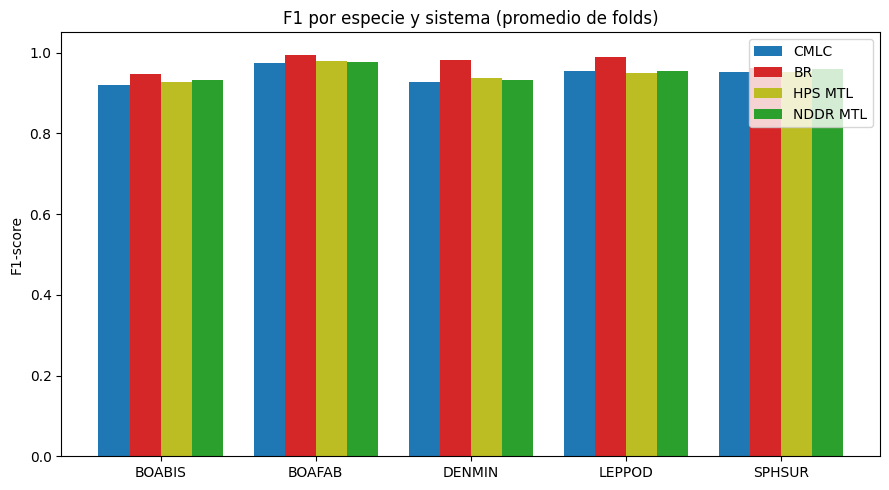

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot_f1.index))
width = 0.8 / max(len(pivot_f1.columns), 1)

for i, sys_label in enumerate(pivot_f1.columns):
    color = SYSTEM_COLORS.get([k for k, v in SYSTEM_LABELS.items() if v == sys_label][0])
    ax.bar(x + i * width, pivot_f1[sys_label], width, label=sys_label, color=color)

ax.set_xticks(x + width * (len(pivot_f1.columns) - 1) / 2)
ax.set_xticklabels(pivot_f1.index)
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
ax.set_title("F1 por especie y sistema (promedio de folds)")
ax.legend()
plt.tight_layout()
plt.savefig("f1_por_especie_sistema.png", dpi=120)
plt.show()


**Nota:** esta celda arma dinámicamente una barra por cada sistema disponible
— con solo CMLC y BR verás 2 barras por especie; al agregar HPS/NDDR, las
barras adicionales aparecen solas sin tocar el código.

## 5. Variabilidad entre folds (min-max), análogo a la Fig. 5 del paper

El paper reporta barras de error mín-máx entre folds para mostrar la
estabilidad de cada sistema. Replicamos esa idea aquí a nivel de F1 global
por sistema.


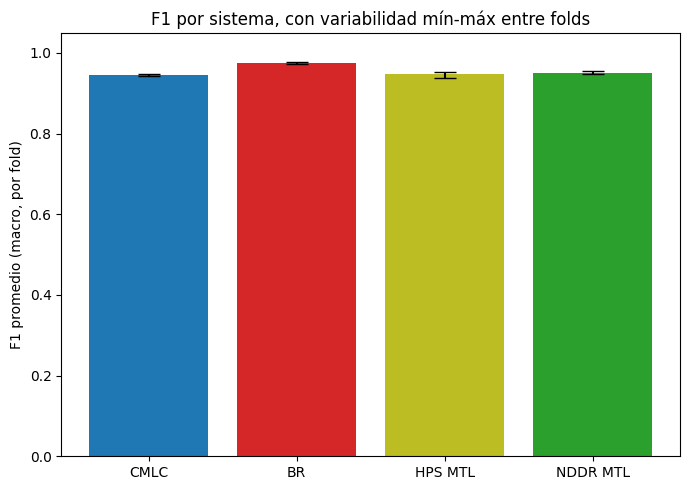

Detalle por fold:
CMLC: {1: 0.9466, 2: 0.9481, 3: 0.9422, 4: 0.9444, 5: 0.9487}
BR: {1: 0.9732, 2: 0.9774, 3: 0.9756, 4: 0.9723, 5: 0.9741}
HPS MTL: {1: 0.9502, 2: 0.9524, 3: 0.9509, 4: 0.9506, 5: 0.9383}
NDDR MTL: {1: 0.9483, 2: 0.9543, 3: 0.9477, 4: 0.9505, 5: 0.952}


In [12]:
fold_f1 = {s: final_dfs[s].groupby("fold")["f1"].mean() for s in available}

fig, ax = plt.subplots(figsize=(7, 5))
means = [fold_f1[s].mean() for s in available]
mins = [fold_f1[s].mean() - fold_f1[s].min() for s in available]
maxs = [fold_f1[s].max() - fold_f1[s].mean() for s in available]
labels = [SYSTEM_LABELS[s] for s in available]
colors = [SYSTEM_COLORS[s] for s in available]

ax.bar(labels, means, yerr=[mins, maxs], capsize=8, color=colors)
ax.set_ylabel("F1 promedio (macro, por fold)")
ax.set_ylim(0, 1.05)
ax.set_title("F1 por sistema, con variabilidad mín-máx entre folds")
plt.tight_layout()
plt.savefig("f1_variabilidad_folds.png", dpi=120)
plt.show()

print("Detalle por fold:")
for s in available:
    print(f"{SYSTEM_LABELS[s]}: {fold_f1[s].round(4).to_dict()}")


## 6. Prevalencia vs. desempeño (análogo a la Fig. 2 del paper)

El paper muestra que la representación de una clase/combinación en el
dataset de entrenamiento influye más en el desempeño que la dificultad
intrínseca. Replicamos esa idea a nivel de especie: comparamos el `support`
(n° de ejemplos positivos en validación) contra el F1 obtenido.


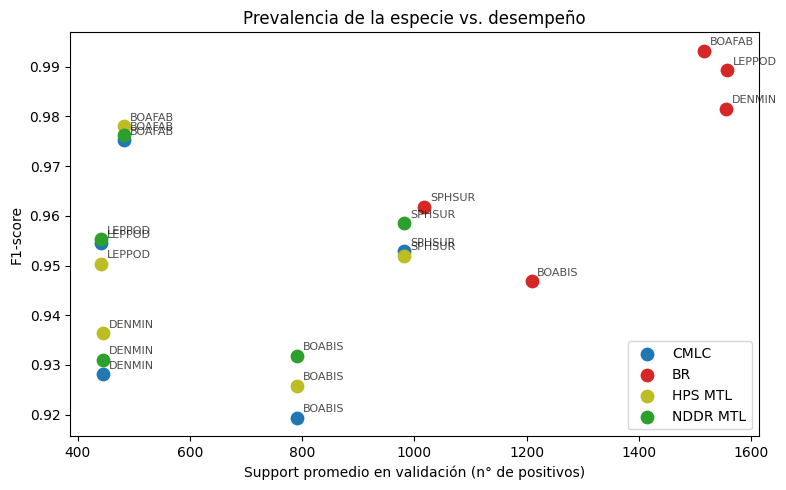

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for s in available:
    df = final_dfs[s].groupby("class").agg(f1=("f1", "mean"), support=("support", "mean"))
    ax.scatter(df["support"], df["f1"], label=SYSTEM_LABELS[s], color=SYSTEM_COLORS[s], s=80)
    for cls, row in df.iterrows():
        ax.annotate(cls, (row["support"], row["f1"]), fontsize=8, alpha=0.7,
                    xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Support promedio en validación (n° de positivos)")
ax.set_ylabel("F1-score")
ax.set_title("Prevalencia de la especie vs. desempeño")
ax.legend()
plt.tight_layout()
plt.savefig("prevalencia_vs_f1.png", dpi=120)
plt.show()


## 7. Curvas de entrenamiento (loss y F1 por época)

Una figura por sistema disponible, mostrando la evolución del F1-macro de
validación a lo largo de las épocas, para cada fold.


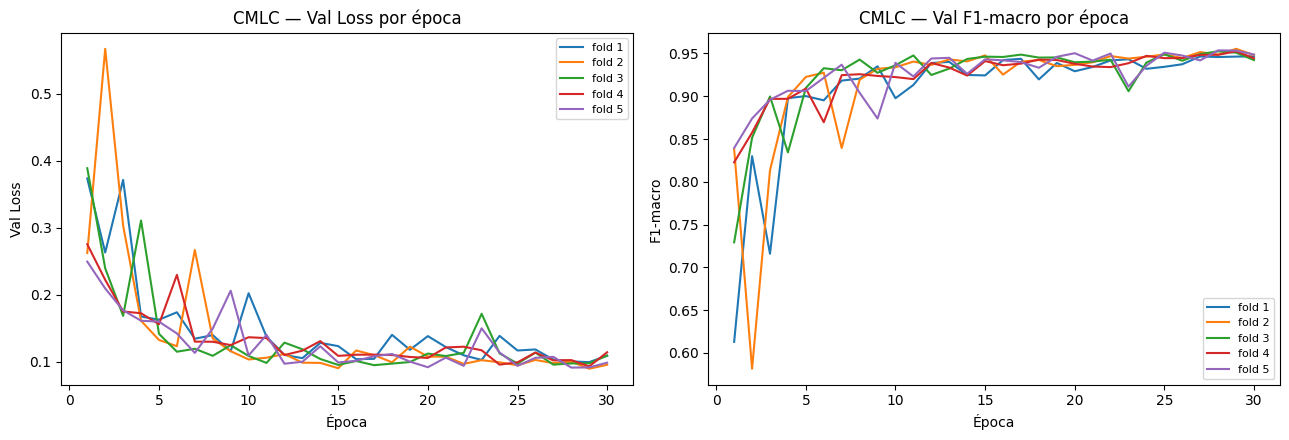

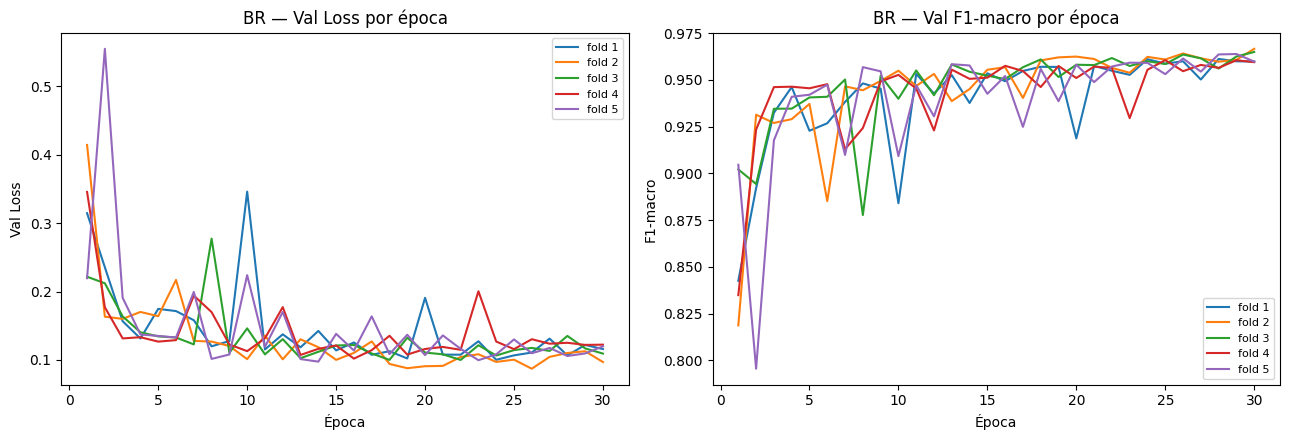

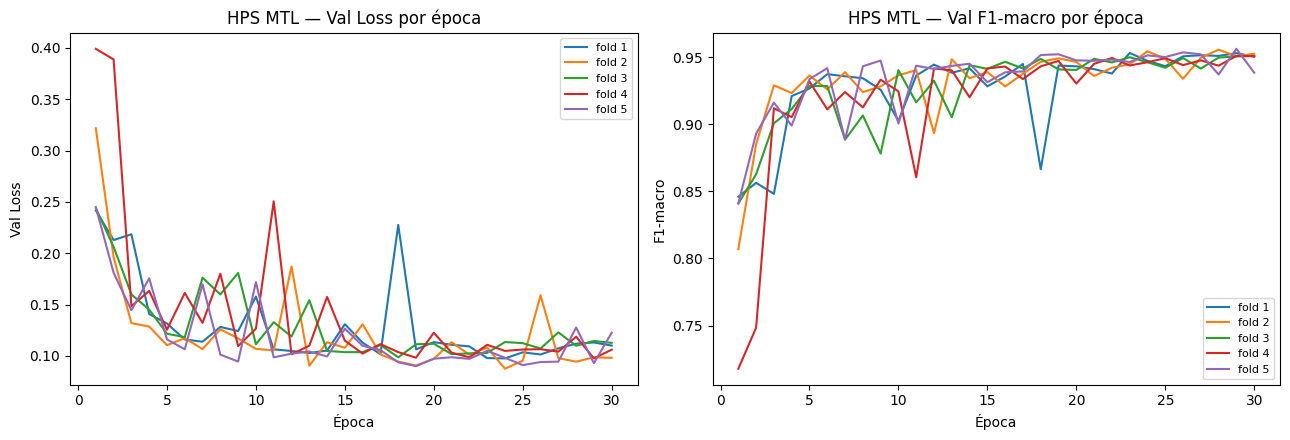

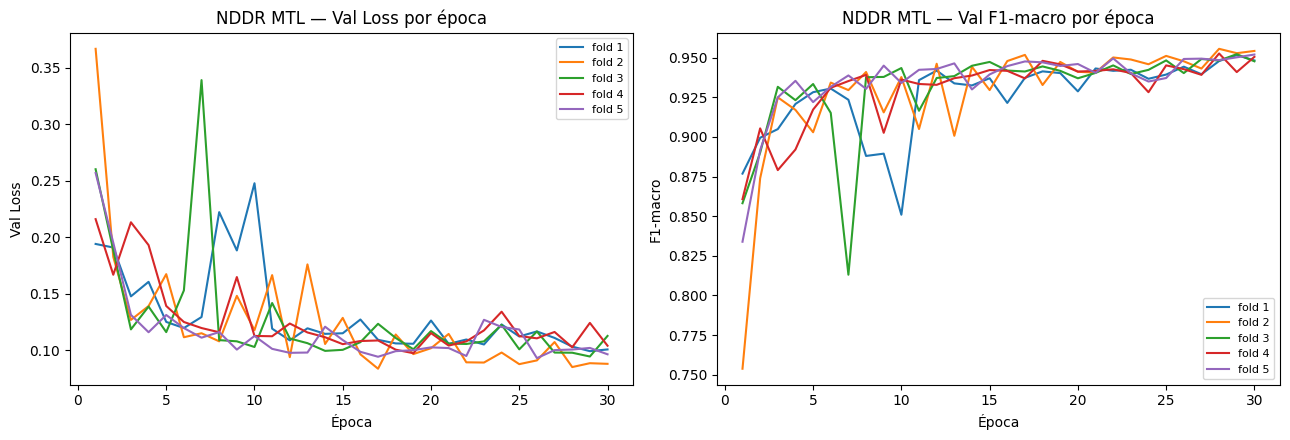

In [14]:
for s in available:
    if s not in epochs_dfs:
        continue
    df = epochs_dfs[s]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for fold in sorted(df["fold"].unique()):
        fold_df = df[df["fold"] == fold].sort_values("epoch")
        # Para BR, agregar (promediar sobre clases) por epoca dentro del fold
        if s == "br":
            fold_df = fold_df.groupby("epoch")[["train_loss", "val_loss", "val_f1_macro"]].mean().reset_index()
        axes[0].plot(fold_df["epoch"], fold_df["val_loss"], label=f"fold {fold}")
        axes[1].plot(fold_df["epoch"], fold_df["val_f1_macro"], label=f"fold {fold}")

    axes[0].set_title(f"{SYSTEM_LABELS[s]} — Val Loss por época")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Val Loss"); axes[0].legend(fontsize=8)
    axes[1].set_title(f"{SYSTEM_LABELS[s]} — Val F1-macro por época")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("F1-macro"); axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"curvas_entrenamiento_{s}.png", dpi=120)
    plt.show()


**Nota sobre BR:** a diferencia de CMLC/HPS/NDDR (un modelo conjunto por
fold), BR entrena un modelo independiente por cada combinación (fold, clase).
La celda de arriba promedia sobre las clases para mostrar una curva por fold,
comparable a la de los otros sistemas — si quieres ver el detalle por especie
dentro de BR, usa la celda siguiente.

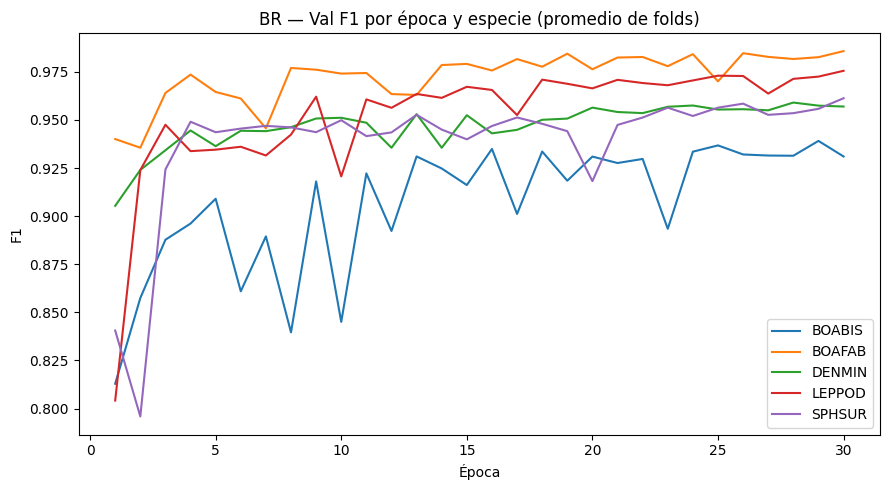

In [15]:
if "br" in epochs_dfs:
    df = epochs_dfs["br"]
    fig, ax = plt.subplots(figsize=(9, 5))
    for cls in sorted(df["class"].unique()):
        cls_df = df[df["class"] == cls].groupby("epoch")["val_f1_macro"].mean()
        ax.plot(cls_df.index, cls_df.values, label=cls)
    ax.set_title("BR — Val F1 por época y especie (promedio de folds)")
    ax.set_xlabel("Época"); ax.set_ylabel("F1")
    ax.legend()
    plt.tight_layout()
    plt.savefig("br_curvas_por_especie.png", dpi=120)
    plt.show()
else:
    print("BR no disponible todavia.")


## 8. Tiempo de cómputo por sistema

Comparación del tiempo promedio por época — relevante para la discusión del
paper sobre el costo computacional relativo de cada arquitectura (BR es
K veces más costoso en total, aunque cada red individual sea liviana).


In [16]:
time_summary = []
for s in available:
    if s not in epochs_dfs:
        continue
    df = epochs_dfs[s]
    avg_epoch_time = df["epoch_time_sec"].mean()
    n_units = df.groupby(["fold"] + (["class"] if s == "br" else [])).ngroups
    total_time_h = df["epoch_time_sec"].sum() / 3600
    time_summary.append({
        "sistema": SYSTEM_LABELS[s],
        "seg/epoca (promedio)": round(avg_epoch_time, 1),
        "unidades entrenadas": n_units,
        "tiempo total (h)": round(total_time_h, 2),
    })

time_df = pd.DataFrame(time_summary)
print(time_df.to_string(index=False))


 sistema  seg/epoca (promedio)  unidades entrenadas  tiempo total (h)
    CMLC                  29.6                    5              1.24
      BR                  29.6                   25              6.17
 HPS MTL                  29.2                    5              1.22
NDDR MTL                  62.6                    5              2.61


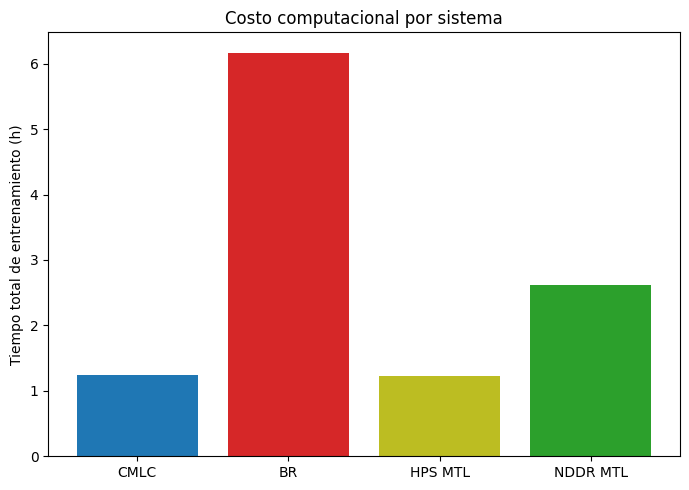

In [17]:
if len(time_summary) > 1:
    fig, ax = plt.subplots(figsize=(7, 5))
    labels = [row["sistema"] for row in time_summary]
    values = [row["tiempo total (h)"] for row in time_summary]
    colors_list = [SYSTEM_COLORS[s] for s in available if s in epochs_dfs]
    ax.bar(labels, values, color=colors_list)
    ax.set_ylabel("Tiempo total de entrenamiento (h)")
    ax.set_title("Costo computacional por sistema")
    plt.tight_layout()
    plt.savefig("tiempo_computo_por_sistema.png", dpi=120)
    plt.show()


## 9. Limitaciones de este análisis

Dos figuras del paper **no se pueden replicar** con lo que `train.py` guarda
por defecto (`results_final.csv`, `results_epochs.csv`), porque requieren las
predicciones individuales (probabilidad por clip de validación):

- **Matriz de confusión entre combinaciones de etiquetas** (Fig. 3 del paper):
  requeriría comparar la combinación exacta predicha vs. la real para cada
  clip de validación.
- **Curvas precision-recall por clase con AUC** (Fig. 4 del paper): requeriría
  las probabilidades de salida (no solo la clasificación binaria con umbral 0.5)
  para cada clip de validación.

(Accuracy y Exact Match, en cambio, sí se pueden recuperar sin reentrenar —
ver Sección 3 — porque `compute_paper_metrics.py` corre inferencia sobre los
checkpoints ya guardados.)

Si se quisiera replicar las dos figuras de arriba, habría que modificar
`compute_paper_metrics.py` para además guardar las probabilidades por clip
(`filename`, clase, probabilidad), no solo las metricas agregadas.


## 10. Conclusiones (completar al tener los 4 sistemas)


In [18]:
if len(available) == len(SYSTEMS):
    best_system = max(available, key=lambda s: final_dfs[s]["f1"].mean())
    print(f"Los 4 sistemas estan disponibles.")
    print(f"Mejor F1-macro global: {SYSTEM_LABELS[best_system]} ({final_dfs[best_system]['f1'].mean():.4f})")
    print()
    print("Ranking completo:")
    ranking = sorted(available, key=lambda s: final_dfs[s]["f1"].mean(), reverse=True)
    for i, s in enumerate(ranking, 1):
        print(f"  {i}. {SYSTEM_LABELS[s]}: F1={final_dfs[s]['f1'].mean():.4f}")
else:
    print(f"Faltan sistemas por completar: {[SYSTEM_LABELS[s] for s in missing]}")
    print("Vuelve a correr este notebook completo cuando esten listos, para "
          "obtener el ranking final y las conclusiones.")


Los 4 sistemas estan disponibles.
Mejor F1-macro global: BR (0.9745)

Ranking completo:
  1. BR: F1=0.9745
  2. NDDR MTL: F1=0.9506
  3. HPS MTL: F1=0.9485
  4. CMLC: F1=0.9460
